In [ ]:
from google.colab import drive

# Step 1: Mount Google Drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import os
from glob import glob

# Step 2: Define dataset root path once
DATASET_ROOT = '/content/drive/MyDrive/dataset_split_brain_tumour'
TRAIN_PATH   = f"{DATASET_ROOT}/train"
VAL_PATH     = f"{DATASET_ROOT}/val"
TEST_PATH    = f"{DATASET_ROOT}/test"

# Auto-resolve paths to .mat files for each split
TRAIN_PATHS = sorted(glob(os.path.join(TRAIN_PATH, '*.mat')))
VAL_PATHS   = sorted(glob(os.path.join(VAL_PATH, '*.mat')))
TEST_PATHS  = sorted(glob(os.path.join(TEST_PATH, '*.mat')))

# Verify file counts
print(f"Train Files: {len(TRAIN_PATHS)}")
print(f"Validation Files: {len(VAL_PATHS)}")
print(f"Test Files: {len(TEST_PATHS)}")


Train Files: 2144
Validation Files: 458
Test Files: 462


In [ ]:
from torch.utils.data import Dataset
import torch
import numpy as np
import cv2
import h5py
import albumentations as A
from albumentations.pytorch import ToTensorV2

class BrainTumorDataset(Dataset):
    """
    Custom Dataset for Brain Tumor MRI classification + segmentation.
    Loads .mat files and applies Albumentations transforms.
    """
    def __init__(self, mat_paths, is_train=False):
        self.file_paths = mat_paths
        self.is_train = is_train

        if self.is_train:
            self.transform = A.Compose([
                A.Resize(224, 224),
                A.HorizontalFlip(p=0.5),
                A.RandomRotate90(p=0.3),
                A.Normalize(mean=(0.485, 0.456, 0.406),
                            std=(0.229, 0.224, 0.225)),
                ToTensorV2()
            ])
        else:
            self.transform = A.Compose([
                A.Resize(224, 224),
                A.Normalize(mean=(0.485, 0.456, 0.406),
                            std=(0.229, 0.224, 0.225)),
                ToTensorV2()
            ])

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        file_path = self.file_paths[idx]
        with h5py.File(file_path, 'r') as f:
            image = np.array(f['cjdata']['image'])[()].T.astype(np.float32)
            mask = np.array(f['cjdata']['tumorMask'])[()].T.astype(np.float32)
            label = int(np.array(f['cjdata']['label'])[()].squeeze()) - 1 # Convert 1/2/3 → 0/1/2

        # Do NOT normalize image to [0, 1] manually — Albumentations expects 0–255 range
        # Convert grayscale to RGB
        image_rgb = np.stack([image] * 3, axis=-1)
        mask = np.expand_dims(mask, axis=-1)

        augmented = self.transform(image=image_rgb, mask=mask)
        image_tensor = augmented['image']
        mask_tensor = augmented['mask'].permute(2, 0, 1)

        return image_tensor, mask_tensor, label


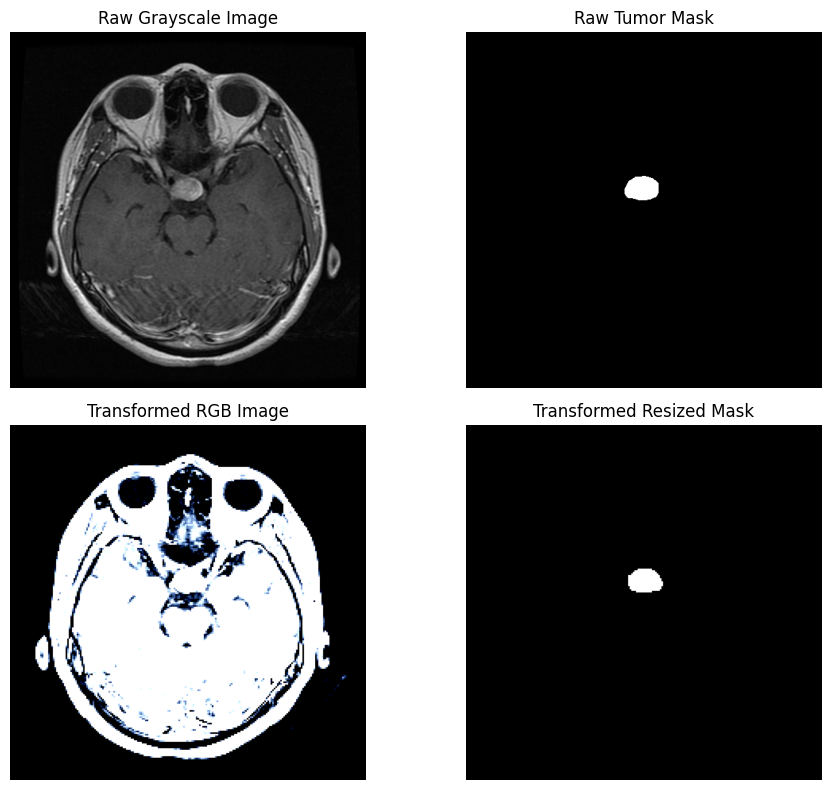

In [ ]:
import matplotlib.pyplot as plt

def visualize_sample(dataset, idx):
    """Visualize raw and transformed images/masks from dataset."""
    # Load the file manually for raw image/mask (no transform)
    file_path = dataset.file_paths[idx]
    with h5py.File(file_path, 'r') as f:
        raw_image = np.array(f['cjdata']['image'])[()].T.astype(np.float32)
        raw_mask = np.array(f['cjdata']['tumorMask'])[()].T.astype(np.float32)

    # Transformed image and mask (uses __getitem__)
    image_tensor, mask_tensor, label = dataset[idx]

    # Convert tensors to numpy arrays
    transformed_image = image_tensor.permute(1, 2, 0).cpu().numpy()
    transformed_mask = mask_tensor.squeeze().cpu().numpy()

    # Plot raw and processed side-by-side
    fig, axs = plt.subplots(2, 2, figsize=(10, 8))
    axs[0, 0].imshow(raw_image, cmap='gray')
    axs[0, 0].set_title("Raw Grayscale Image")
    axs[0, 1].imshow(raw_mask, cmap='gray')
    axs[0, 1].set_title("Raw Tumor Mask")
    axs[1, 0].imshow(transformed_image)
    axs[1, 0].set_title("Transformed RGB Image")
    axs[1, 1].imshow(transformed_mask, cmap='gray')
    axs[1, 1].set_title("Transformed Resized Mask")

    for ax in axs.ravel():
        ax.axis("off")
    plt.tight_layout()
    plt.show()

sample_dataset = BrainTumorDataset(TRAIN_PATHS, is_train=True)
visualize_sample(sample_dataset, idx=5)


In [ ]:
from torch.utils.data import DataLoader

# Create dataset instances
train_dataset = BrainTumorDataset(TRAIN_PATHS, is_train=True)
val_dataset   = BrainTumorDataset(VAL_PATHS, is_train=False)
test_dataset  = BrainTumorDataset(TEST_PATHS, is_train=False)

# Recommended settings for T4 GPU
BATCH_SIZE = 16
NUM_WORKERS = 2

# Wrap into DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

# Optional check: View one batch
for images, masks, labels in train_loader:
    print("Train Batch → Images:", images.shape, "| Masks:", masks.shape, "| Labels:", labels.shape)
    break


Train Batch → Images: torch.Size([16, 3, 224, 224]) | Masks: torch.Size([16, 1, 224, 224]) | Labels: torch.Size([16])


In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models
from torchvision.models import DenseNet121_Weights
import torch.nn.functional as F

class DualHeadDenseNet(nn.Module):
    """
    DenseNet-121 backbone with two heads:
    1) Classification head (global average pooling + FC)
    2) Segmentation head (U-Net style decoder with skip connections)

    Notes on channel sizes (DenseNet-121):
      - after conv0 / pool0 -> x1: 256 channels (56x56)
      - after denseblock2     -> x2: 512 channels (28x28)
      - after denseblock3     -> x3: 1024 channels (14x14)
      - after denseblock4     -> x4/features: 1024 channels (7x7)
    Decoder convs are defined to accept the concatenated channel counts.
    """
    def __init__(self, num_classes=3):
        super(DualHeadDenseNet, self).__init__()

        # Load DenseNet-121 backbone with ImageNet weights
        backbone = models.densenet121(weights=DenseNet121_Weights.IMAGENET1K_V1)

        # Extract DenseNet feature layers for encoder and skip-connections
        self.conv0 = backbone.features.conv0    # -> 64
        self.norm0 = backbone.features.norm0
        self.relu0 = backbone.features.relu0
        self.pool0 = backbone.features.pool0

        self.denseblock1 = backbone.features.denseblock1  # -> 256
        self.trans1 = backbone.features.transition1

        self.denseblock2 = backbone.features.denseblock2  # -> 512
        self.trans2 = backbone.features.transition2

        self.denseblock3 = backbone.features.denseblock3  # -> 1024
        self.trans3 = backbone.features.transition3

        self.denseblock4 = backbone.features.denseblock4  # -> 1024
        self.norm5 = backbone.features.norm5

        # ---------------- Classification Head ----------------
        # global pooling + linear
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),  # [B, 1024, 1, 1]
            nn.Flatten(),                  # [B, 1024]
            nn.Linear(1024, num_classes)   # [B, num_classes]
        )

        # ---------------- Segmentation Decoder ----------------
        # We'll create conv layers that accept the post-concat channel sizes.
        # Decoder stage 1: from bottleneck features (1024) -> 512, up -> 14x14
        self.up1_conv = nn.Sequential(
            nn.Conv2d(1024, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True)
        )
        # After concat with x3 (1024) => 512 + 1024 = 1536 -> to 256
        self.up2_conv = nn.Sequential(
            nn.Conv2d(1536, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True)
        )
        # After concat with x2 (512) => 256 + 512 = 768 -> to 128
        self.up3_conv = nn.Sequential(
            nn.Conv2d(768, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True)
        )
        # After concat with x1 (256) => 128 + 256 = 384 -> to 64
        self.up4_conv = nn.Sequential(
            nn.Conv2d(384, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True)
        )
        # Final conv to produce single-channel mask (logits)
        self.final_conv = nn.Conv2d(64, 1, kernel_size=1)

    def forward(self, x):
        """
        Forward pass:
        - Encoder: produce skip features x1, x2, x3 and bottleneck features
        - Classification head: global pool -> linear
        - Decoder: upsample + concat skips -> segmentation logits
        Returns:
            class_logits: [B, num_classes]
            seg_output:   [B, 1, 224, 224] (logits)
        """
        # -------- Encoder (DenseNet) --------
        x0 = self.relu0(self.norm0(self.conv0(x)))  # [B, 64, 112,112]
        x1 = self.pool0(x0)                         # pool -> [B,64,56,56]
        x1 = self.denseblock1(x1)                   # [B,256,56,56]

        x2 = self.trans1(x1)
        x2 = self.denseblock2(x2)                   # [B,512,28,28]

        x3 = self.trans2(x2)
        x3 = self.denseblock3(x3)                   # [B,1024,14,14]

        x4 = self.trans3(x3)
        x4 = self.denseblock4(x4)                   # [B,1024,7,7]
        features = self.norm5(x4)                   # [B,1024,7,7]

        # -------- Classification Head --------
        class_logits = self.classifier(features)    # [B, num_classes]

        # -------- Decoder with U-Net style skip connections --------
        # Stage 1: bottleneck -> up to 14x14
        d = self.up1_conv(features)                 # [B,512,7,7]
        d = F.interpolate(d, scale_factor=2, mode='bilinear', align_corners=False)  # -> [B,512,14,14]
        d = torch.cat([d, x3], dim=1)               # concat skip x3 -> [B,1536,14,14]

        # Stage 2: process concat -> up to 28x28
        d = self.up2_conv(d)                        # [B,256,14,14]
        d = F.interpolate(d, scale_factor=2, mode='bilinear', align_corners=False)  # -> [B,256,28,28]
        d = torch.cat([d, x2], dim=1)               # concat skip x2 -> [B,768,28,28]

        # Stage 3: process concat -> up to 56x56
        d = self.up3_conv(d)                        # [B,128,28,28]
        d = F.interpolate(d, scale_factor=2, mode='bilinear', align_corners=False)  # -> [B,128,56,56]
        d = torch.cat([d, x1], dim=1)               # concat skip x1 -> [B,384,56,56]

        # Stage 4: process -> up to 224x224
        d = self.up4_conv(d)                        # [B,64,56,56]
        d = F.interpolate(d, scale_factor=4, mode='bilinear', align_corners=False)  # -> [B,64,224,224]

        seg_output = self.final_conv(d)             # [B,1,224,224] (logits)

        return class_logits, seg_output



In [ ]:
model = DualHeadDenseNet()
out_cls, out_seg = model(torch.randn(16, 3, 224, 224))  # Test input
print("Classification:", out_cls.shape)   # → [16, 3]
print("Segmentation :", out_seg.shape)    # → [16, 1, 224, 224]


Classification: torch.Size([16, 3])
Segmentation : torch.Size([16, 1, 224, 224])


In [ ]:
import torch
import torch.nn as nn

# ---------------- Loss Functions ---------------- #
classification_criterion = nn.CrossEntropyLoss()
segmentation_bce = nn.BCEWithLogitsLoss()

class DiceLoss(nn.Module):
    """Dice Loss for segmentation."""
    def __init__(self, smooth=1e-6):
        super(DiceLoss, self).__init__()
        self.smooth = smooth

    def forward(self, preds, targets):
        # preds: logits -> apply sigmoid inside dice
        preds = torch.sigmoid(preds)
        preds = preds.view(-1)
        targets = targets.view(-1)
        intersection = (preds * targets).sum()
        dice = (2. * intersection + self.smooth) / (preds.sum() + targets.sum() + self.smooth)
        return 1 - dice

dice_loss = DiceLoss()

def combined_segmentation_loss(preds, targets, bce_weight=0.5):
    """Weighted sum of BCEWithLogitsLoss and DiceLoss."""
    bce = segmentation_bce(preds, targets)
    dice = dice_loss(preds, targets)
    return bce_weight * bce + (1 - bce_weight) * dice

def total_loss_fn(class_logits, seg_output, class_labels, seg_masks, alpha=1.0, beta=1.0):
    """Total loss = alpha * classification loss + beta * segmentation loss."""
    classification_loss = classification_criterion(class_logits, class_labels)
    segmentation_loss = combined_segmentation_loss(seg_output, seg_masks)
    return alpha * classification_loss + beta * segmentation_loss


In [ ]:
import time
import numpy as np
from tqdm import tqdm

# ---------------- Device & Model ---------------- #
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = DualHeadDenseNet(num_classes=3).to(device)

# ---------------- Optimizer & Scheduler ---------------- #
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=3, factor=0.5
)

# ---------------- Training Setup ---------------- #
num_epochs = 20
early_stop_patience = 5
epochs_no_improve = 0
best_val_loss = float('inf')

train_losses, val_losses, epoch_times = [], [], []
train_accs, val_accs, val_dice_scores = [], [], []

# ---------------- Training Loop ---------------- #
for epoch in range(num_epochs):
    print(f"\nEpoch {epoch+1}/{num_epochs}")
    print("-" * 40)
    start_time = time.time()

    # -------- Training --------
    model.train()
    train_loss, train_correct, train_total = 0, 0, 0
    loop = tqdm(train_loader, desc="Training", leave=False)

    for images, masks, labels in loop:
        images, masks, labels = images.to(device), masks.to(device), labels.to(device)

        optimizer.zero_grad()
        class_logits, seg_output = model(images)
        loss = total_loss_fn(class_logits, seg_output, labels, masks)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        preds = torch.argmax(class_logits, dim=1)
        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)
        loop.set_postfix(loss=loss.item())

    # -------- Validation --------
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0
    dice_scores = []

    with torch.no_grad():
        loop = tqdm(val_loader, desc="Validation", leave=False)
        for images, masks, labels in loop:
            images, masks, labels = images.to(device), masks.to(device), labels.to(device)

            class_logits, seg_output = model(images)
            loss = total_loss_fn(class_logits, seg_output, labels, masks)

            val_loss += loss.item()
            preds = torch.argmax(class_logits, dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

            pred_mask = torch.sigmoid(seg_output) > 0.5
            # compute dice per-sample
            intersection = (pred_mask & masks.bool()).float().sum((1, 2, 3))
            union = pred_mask.float().sum((1, 2, 3)) + masks.float().sum((1, 2, 3))
            dice = (2. * intersection + 1e-6) / (union + 1e-6)
            dice_scores.append(dice.mean().item())

            loop.set_postfix(val_loss=loss.item())

    # -------- Epoch Stats --------
    avg_train_loss = train_loss / len(train_loader)
    avg_val_loss = val_loss / len(val_loader)
    train_acc = train_correct / train_total
    val_acc = val_correct / val_total
    avg_dice = np.mean(dice_scores)
    epoch_time = time.time() - start_time

    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)
    val_dice_scores.append(avg_dice)
    epoch_times.append(epoch_time)

    print(f"Train Loss: {avg_train_loss:.4f} | Acc: {train_acc:.4f}")
    print(f"Val   Loss: {avg_val_loss:.4f} | Acc: {val_acc:.4f} | Dice: {avg_dice:.4f}")
    print(f"Epoch Time: {epoch_time:.2f}s")

    scheduler.step(avg_val_loss)

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        # Save model to dataset root
        torch.save(model.state_dict(), f"{DATASET_ROOT}/best_model_DenseNet121_Dualhead.pth")
        print("Best model saved.")
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        print(f"No improvement ({epochs_no_improve}/{early_stop_patience})")

    if epochs_no_improve >= early_stop_patience:
        print("Early stopping triggered.")
        break

print("\nTraining complete.")



Epoch 1/20
----------------------------------------


Train Loss: 0.9716 | Acc: 0.8769
Val   Loss: 0.8203 | Acc: 0.8996 | Dice: 0.4286
Epoch Time: 927.25s
Best model saved.

Epoch 2/20
----------------------------------------


Train Loss: 0.7053 | Acc: 0.9492
Val   Loss: 0.6806 | Acc: 0.9476 | Dice: 0.5799
Epoch Time: 50.39s
Best model saved.

Epoch 3/20
----------------------------------------


Train Loss: 0.6065 | Acc: 0.9618
Val   Loss: 0.5759 | Acc: 0.9716 | Dice: 0.5771
Epoch Time: 50.07s
Best model saved.

Epoch 4/20
----------------------------------------


Train Loss: 0.5298 | Acc: 0.9776
Val   Loss: 0.5087 | Acc: 0.9760 | Dice: 0.6518
Epoch Time: 50.30s
Best model saved.

Epoch 5/20
----------------------------------------


...

Train Loss: 0.1344 | Acc: 0.9925
Val   Loss: 0.1588 | Acc: 0.9847 | Dice: 0.7734
Epoch Time: 50.81s
Best model saved.

Epoch 17/20
----------------------------------------


Train Loss: 0.1198 | Acc: 0.9949
Val   Loss: 0.1546 | Acc: 0.9891 | Dice: 0.7677
Epoch Time: 50.60s
Best model saved.

Epoch 18/20
----------------------------------------


Train Loss: 0.1258 | Acc: 0.9930
Val   Loss: 0.2077 | Acc: 0.9760 | Dice: 0.7784
Epoch Time: 51.91s
No improvement (1/5)

Epoch 19/20
----------------------------------------


Train Loss: 0.1254 | Acc: 0.9944
Val   Loss: 0.1329 | Acc: 0.9891 | Dice: 0.7837
Epoch Time: 52.00s
Best model saved.

Epoch 20/20
----------------------------------------


Train Loss: 0.1000 | Acc: 0.9986
Val   Loss: 0.1629 | Acc: 0.9847 | Dice: 0.7748
Epoch Time: 50.81s
No improvement (1/5)

Training complete.


In [ ]:
import torch
import torch.nn.functional as F
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_auc_score
import numpy as np
import time

# ----------------- Load Model ----------------- #
model = DualHeadDenseNet(num_classes=3).to(device)
model.load_state_dict(torch.load(f"{DATASET_ROOT}/best_model_DenseNet121_Dualhead.pth"))
model.eval()

# ----------------- Storage ----------------- #
y_true, y_pred = [], []
y_score = []               # store class probabilities for ROC-AUC
dice_scores, ious, pixel_accuracies = [], [], []

start_time = time.time()

# ----------------- Evaluation Loop ----------------- #
with torch.no_grad():
    for images, masks, labels in test_loader:
        images, masks, labels = images.to(device), masks.to(device), labels.to(device)

        class_logits, seg_output = model(images)

        # Classification
        probs = F.softmax(class_logits, dim=1)
        preds = torch.argmax(probs, dim=1)
        y_true.extend(labels.cpu().tolist())
        y_pred.extend(preds.cpu().tolist())
        y_score.extend(probs.cpu().numpy())  # shape: [batch, num_classes]

        # Segmentation
        pred_masks = torch.sigmoid(seg_output) > 0.5
        masks_bool = masks > 0.5

        intersection = (pred_masks & masks_bool).float().sum((1, 2, 3))
        union = (pred_masks | masks_bool).float().sum((1, 2, 3))

        dice = (2 * intersection / (pred_masks.float().sum((1, 2, 3)) + masks_bool.float().sum((1, 2, 3)) + 1e-6)).cpu()
        iou = (intersection / (union + 1e-6)).cpu()
        per_sample_acc = ((pred_masks == masks_bool).float().sum((1, 2, 3)) / (masks_bool[0].numel())).cpu()

        dice_scores.extend(dice.numpy())
        ious.extend(iou.numpy())
        pixel_accuracies.extend(per_sample_acc.numpy())

end_time = time.time()
total_time = end_time - start_time
avg_time_per_batch = total_time / len(test_loader)

# ----------------- Overall Metrics (classification) ----------------- #
acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, average='macro', zero_division=0)
rec = recall_score(y_true, y_pred, average='macro', zero_division=0)
f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)

# ROC / AUC (multi-class one-vs-rest)
n_classes = 3
y_true_bin = label_binarize(y_true, classes=list(range(n_classes)))
y_score_arr = np.array(y_score)

# Macro, Micro, Weighted ROC-AUC
try:
    roc_auc_macro = roc_auc_score(y_true_bin, y_score_arr, average='macro', multi_class='ovr')
    roc_auc_micro = roc_auc_score(y_true_bin, y_score_arr, average='micro', multi_class='ovr')
    roc_auc_weighted = roc_auc_score(y_true_bin, y_score_arr, average='weighted', multi_class='ovr')
except ValueError:
    roc_auc_macro = roc_auc_micro = roc_auc_weighted = float('nan')

# Per-class ROC-AUC with proper tumor names
class_names = ['Meningioma', 'Glioma', 'Pituitary tumor']
per_class_auc = {}

for i, name in enumerate(class_names):
    try:
        auc_val = roc_auc_score(y_true_bin[:, i], y_score_arr[:, i])
    except ValueError:
        auc_val = float('nan')
    per_class_auc[name] = auc_val

# ----------------- Final Report ----------------- #
print("\n Classification Metrics")
print(f"Accuracy       : {acc:.4f}")
print(f"Precision      : {prec:.4f}")
print(f"Recall         : {rec:.4f}")
print(f"F1 Score       : {f1:.4f}")
print(f"ROC-AUC Macro  : {roc_auc_macro if not np.isnan(roc_auc_macro) else 'N/A'}")
print(f"ROC-AUC Micro  : {roc_auc_micro if not np.isnan(roc_auc_micro) else 'N/A'}")
print(f"ROC-AUC Weighted: {roc_auc_weighted if not np.isnan(roc_auc_weighted) else 'N/A'}")

print("\nPer-class ROC-AUC:")
for name, auc_value in per_class_auc.items():
    print(f"{name} : {auc_value:.4f}" if not np.isnan(auc_value) else f"{name} : N/A")

print("\n Segmentation Metrics")
print(f"Avg Dice     : {np.mean(dice_scores):.4f}")
print(f"Avg IoU      : {np.mean(ious):.4f}")
print(f"Pixel Acc.   : {np.mean(pixel_accuracies):.4f}")

print("\n Inference Time")
print(f"Total        : {total_time:.2f} seconds")
print(f"Per Batch    : {avg_time_per_batch:.4f} seconds")



 Classification Metrics
Accuracy       : 0.9913
Precision      : 0.9890
Recall         : 0.9898
F1 Score       : 0.9894
ROC-AUC Macro  : 0.999866499357983
ROC-AUC Micro  : 0.9999062986075974
ROC-AUC Weighted: 0.999899320636789

Per-class ROC-AUC:
Meningioma : 0.9997
Glioma : 1.0000
Pituitary tumor : 0.9999

 Segmentation Metrics
Avg Dice     : 0.7691
Avg IoU      : 0.6738
Pixel Acc.   : 0.9941

 Inference Time
Total        : 6.71 seconds
Per Batch    : 0.2313 seconds


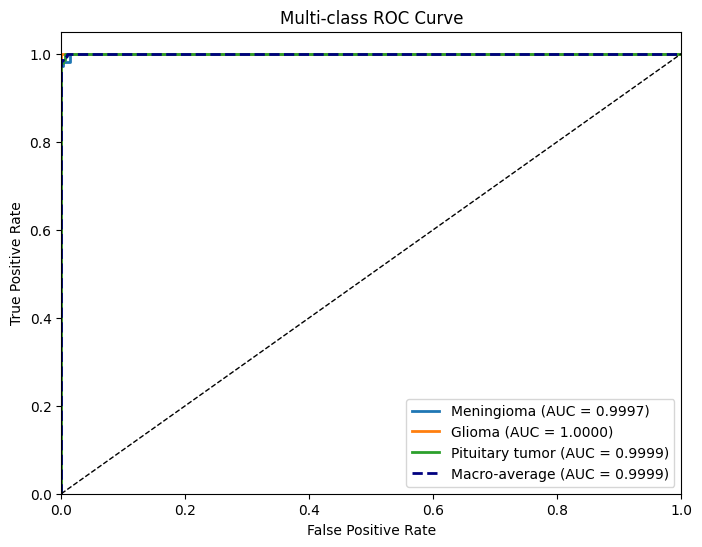

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Tumor class names
class_names = ['Meningioma', 'Glioma', 'Pituitary tumor']

# Plot ROC curve for each class
plt.figure(figsize=(8, 6))
for i, name in enumerate(class_names):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_score_arr[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.4f})')

# Plot macro-average ROC curve
fpr_macro, tpr_macro, _ = roc_curve(y_true_bin.ravel(), y_score_arr.ravel())
roc_auc_macro_vis = auc(fpr_macro, tpr_macro)
plt.plot(fpr_macro, tpr_macro, color='navy', linestyle='--',
         label=f'Macro-average (AUC = {roc_auc_macro_vis:.4f})', lw=2)

# Plot reference line
plt.plot([0, 1], [0, 1], 'k--', lw=1)

# Styling
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-class ROC Curve')
plt.legend(loc='lower right')
plt.show()



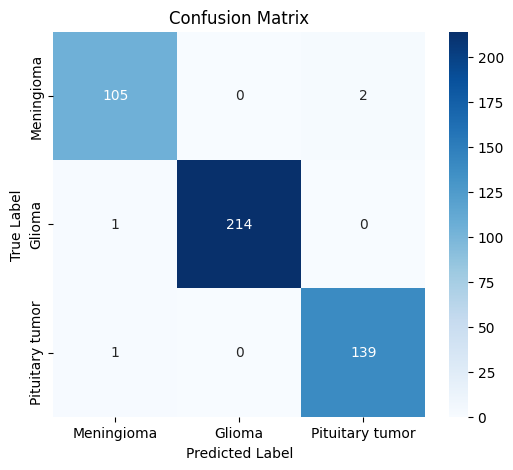

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Compute Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
class_names = ['Meningioma', 'Glioma','Pituitary tumor']

# Plot Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()


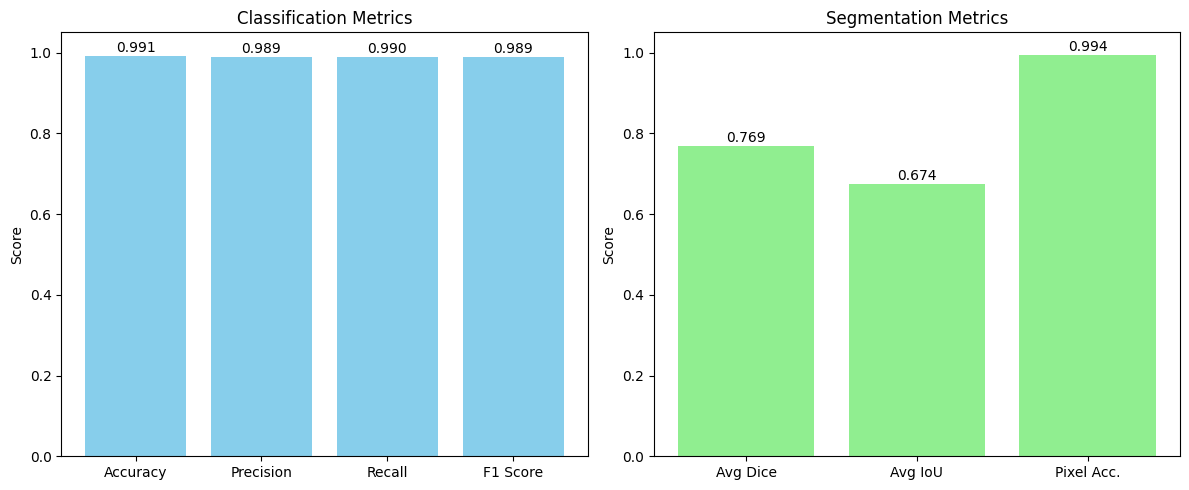

In [ ]:
import matplotlib.pyplot as plt

# ---- Classification metrics ---- #
classification_metrics = {
    "Accuracy": acc,
    "Precision": prec,
    "Recall": rec,
    "F1 Score": f1,

}

# ---- Segmentation metrics ---- #
segmentation_metrics = {
    "Avg Dice": np.mean(dice_scores),
    "Avg IoU": np.mean(ious),
    "Pixel Acc.": np.mean(pixel_accuracies)
}

# ---- Plot ---- #
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Classification
axes[0].bar(classification_metrics.keys(), classification_metrics.values(), color='skyblue')
axes[0].set_ylim(0, 1.05)
axes[0].set_title("Classification Metrics")
axes[0].set_ylabel("Score")
for i, v in enumerate(classification_metrics.values()):
    axes[0].text(i, v + 0.01, f"{v:.3f}", ha='center')

# Segmentation
axes[1].bar(segmentation_metrics.keys(), segmentation_metrics.values(), color='lightgreen')
axes[1].set_ylim(0, 1.05)
axes[1].set_title("Segmentation Metrics")
axes[1].set_ylabel("Score")
for i, v in enumerate(segmentation_metrics.values()):
    axes[1].text(i, v + 0.01, f"{v:.3f}", ha='center')

plt.tight_layout()
plt.show()


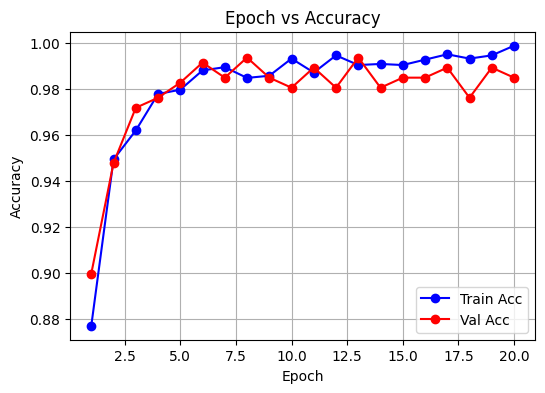

In [ ]:
import matplotlib.pyplot as plt

epochs = range(1, len(train_accs) + 1)

# Epoch vs Accuracy
plt.figure(figsize=(6,4))
plt.plot(epochs, train_accs, 'bo-', label='Train Acc')
plt.plot(epochs, val_accs, 'ro-', label='Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Epoch vs Accuracy')
plt.legend()
plt.grid(True)
plt.show()



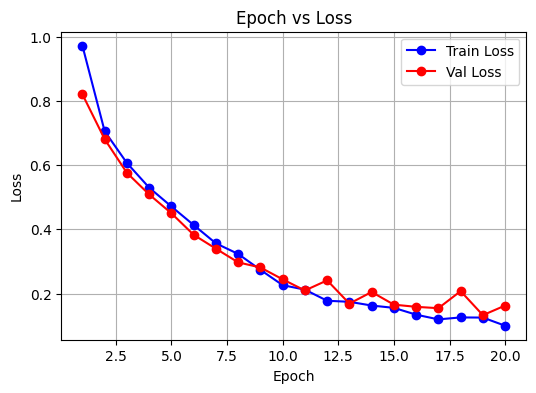

In [ ]:
import matplotlib.pyplot as plt

epochs = range(1, len(train_accs) + 1)

# Epoch vs Loss
plt.figure(figsize=(6,4))
plt.plot(epochs, train_losses, 'bo-', label='Train Loss')
plt.plot(epochs, val_losses, 'ro-', label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Epoch vs Loss')
plt.legend()
plt.grid(True)
plt.show()


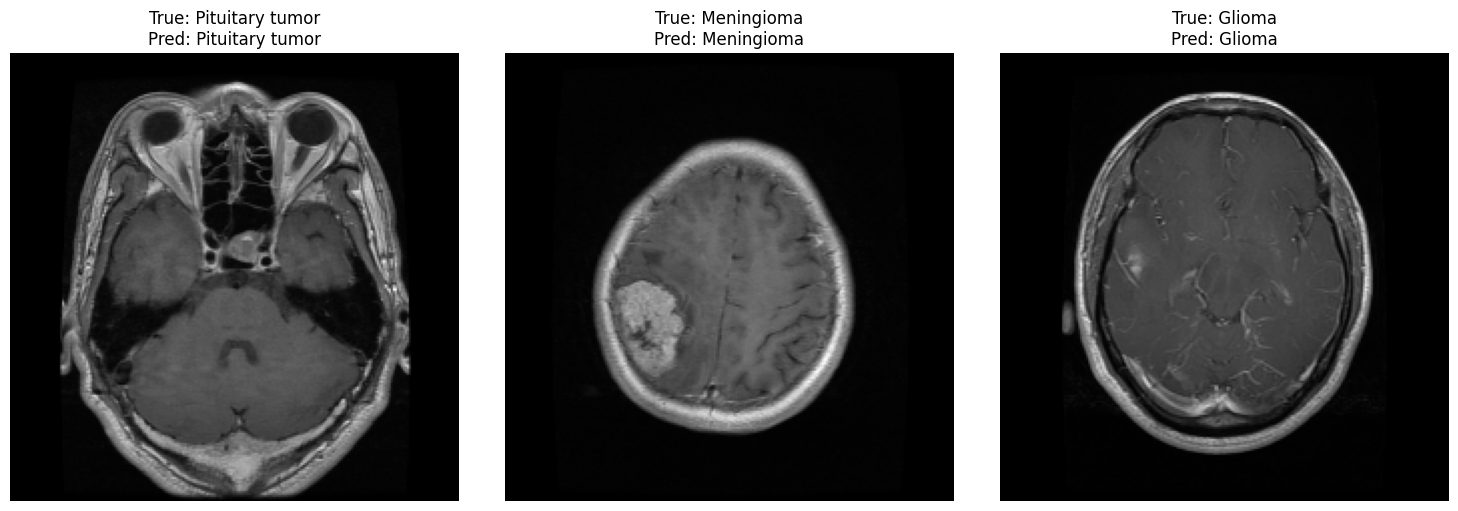

In [ ]:
import matplotlib.pyplot as plt
import torch.nn.functional as F

# Tumor class names
class_names = ['Meningioma', 'Glioma', 'Pituitary tumor']

# Load best saved model
model = DualHeadDenseNet(num_classes=3).to(device)
model.load_state_dict(torch.load(f"{DATASET_ROOT}/best_model_DenseNet121_Dualhead.pth"))
model.eval()

# Keep track of shown classes
shown_classes = set()

plt.figure(figsize=(15, 5))

with torch.no_grad():
    for images, _, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        # Forward pass (classification only)
        class_logits, _ = model(images)
        preds = torch.argmax(F.softmax(class_logits, dim=1), dim=1)

        for i in range(images.size(0)):
            true_class = labels[i].item()

            if true_class not in shown_classes:
                # Convert tensor to numpy image
                img = images[i].cpu().numpy().transpose(1, 2, 0)
                img = img.mean(axis=2)  # grayscale for display

                true_label = class_names[true_class]
                pred_label = class_names[preds[i].item()]

                plt.subplot(1, 3, len(shown_classes) + 1)
                plt.imshow(img, cmap='gray')
                plt.title(f"True: {true_label}\nPred: {pred_label}")
                plt.axis('off')

                shown_classes.add(true_class)

            if len(shown_classes) == 3:
                break
        if len(shown_classes) == 3:
            break

plt.tight_layout()
plt.show()


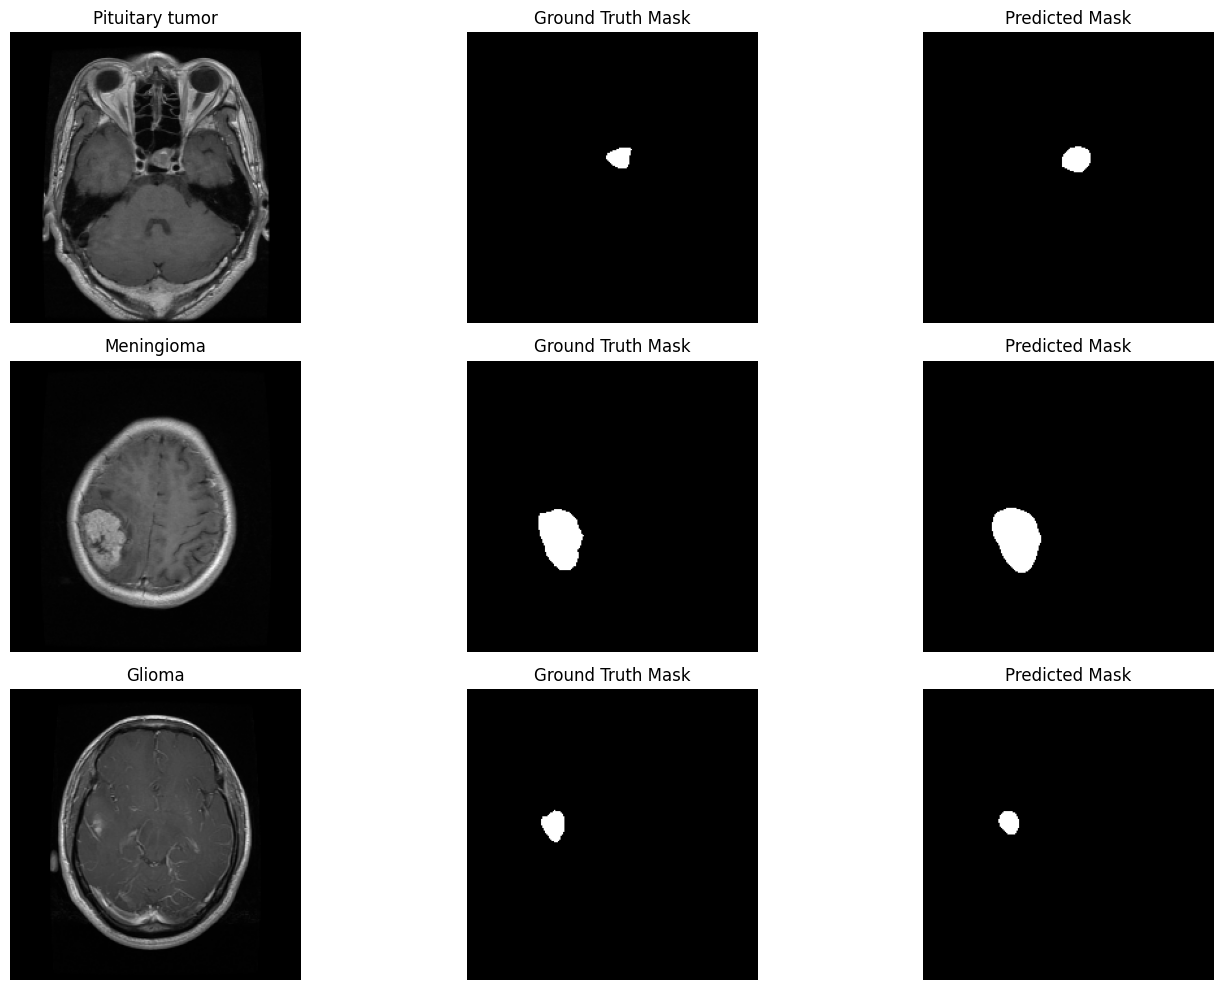

In [ ]:
import matplotlib.pyplot as plt
import torch.nn.functional as F

# Tumor class names
class_names = ['Meningioma', 'Glioma', 'Pituitary tumor']

# Load trained model
model = DualHeadDenseNet(num_classes=3).to(device)
model.load_state_dict(torch.load(f"{DATASET_ROOT}/best_model_DenseNet121_Dualhead.pth"))
model.eval()

# Track shown classes
shown_classes = set()
plt.figure(figsize=(15, 10))

with torch.no_grad():
    for images, masks, labels in test_loader:
        images, masks, labels = images.to(device), masks.to(device), labels.to(device)

        # Forward pass
        _, pred_masks = model(images)
        pred_masks = (torch.sigmoid(pred_masks) > 0.5).float()

        for i in range(images.size(0)):
            true_class = labels[i].item()

            if true_class not in shown_classes:
                # Original MRI image
                img = images[i].cpu().numpy().transpose(1, 2, 0)
                img = img.mean(axis=2)  # grayscale

                # Ground truth & predicted masks
                gt_mask = masks[i].cpu().squeeze().numpy()
                pred_mask = pred_masks[i].cpu().squeeze().numpy()

                base_idx = len(shown_classes) * 3 + 1

                # Original MRI
                plt.subplot(3, 3, base_idx)
                plt.imshow(img, cmap='gray')
                plt.title(f"{class_names[true_class]}")
                plt.axis('off')

                # Ground Truth Mask
                plt.subplot(3, 3, base_idx + 1)
                plt.imshow(gt_mask, cmap='gray')
                plt.title("Ground Truth Mask")
                plt.axis('off')

                # Predicted Mask
                plt.subplot(3, 3, base_idx + 2)
                plt.imshow(pred_mask, cmap='gray')
                plt.title("Predicted Mask")
                plt.axis('off')

                shown_classes.add(true_class)

            if len(shown_classes) == 3:
                break
        if len(shown_classes) == 3:
            break

plt.tight_layout()
plt.show()
